# Phase 2G: cross-scale geometric correspondence diagnostics

## Scope

This notebook asks whether collective, focal, prospectively fixed local-configuration, opponent-relational, and ball-relative descriptions change in interpretable correspondence within the same fixed sequences. It is descriptive only: correspondence and co-occurrence do not imply causal propagation, responsibility, attacker influence, a state, or a score. The exact Phase 2D–2F windows and Phase 2E/2F start-fixed rules are reused; no case, membership, or opponent is replaced after inspection.

## Descriptive templates fixed before comparison

| Template | Broad geometric description | Complication/falsification |
|---|---|---|
| Collective-dominant | Large collective movement with comparatively limited focal/local departure | Internal or focal changes are comparable to collective translation |
| Focal-dominant | Focal collective-relative departure is prominent while other scales differ or are weaker | Local configuration changes equally strongly or focal change is collective |
| Local-within-collective | Local deformation coexists with substantial collective translation | Local account disappears under prospective membership |
| Provisionally multi-scale | Focal, local, and opponent geometry all change while centroid alone is insufficient | Ball/shared motion or membership sensitivity supplies an equally plausible account |
| Heterogeneous/unresolved | Scales change in mixed or contradictory ways | A stable raw-geometric pattern is visible without selective rules |

These are overlapping reading aids, not classes. A case may fit several or none; no frame labels or thresholds are created.

In [1]:
from pathlib import Path
import itertools, hashlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().resolve(); ROOT=ROOT.parent if ROOT.name=='notebooks' else ROOT
DATA=ROOT/'data'/'metrica_sample_game_1'; L,W=105.,68.
HP=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AP=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'; EP=DATA/'Sample_Game_1_RawEventsData.csv'
def load(p,t):
 h=pd.read_csv(p,header=None,nrows=3); ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]; cols=['Period','Frame','Time [s]']
 for x in ids: cols += [f'{t}_{x}_x',f'{t}_{x}_y']
 cols += [f'{t}_ball_x',f'{t}_ball_y']; return pd.read_csv(p,skiprows=3,names=cols),ids
home,hp=load(HP,'Home'); away,ap=load(AP,'Away'); events=pd.read_csv(EP)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; gk={'Home':'11','Away':'25'}
print({'Home':home.shape,'Away':away.shape,'events':events.shape})

{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


In [2]:
CASES=[
 {'short':'1888 translation','period':1,'start':1888.,'end':1896.,'dt':'Home','f':'2','ot':'Away'},
 {'short':'590 excursion','period':1,'start':590.,'end':598.,'dt':'Home','f':'2','ot':'Away'},
 {'short':'550.76 tackle','period':1,'start':550.76,'end':555.76,'dt':'Away','f':'16','ot':'Home','anchor':550.76},
 {'short':'1230 interior','period':1,'start':1228.12,'end':1232.12,'dt':'Away','f':'19','ot':'Home','anchor':1230.12},
 {'short':'1232 reference-sensitive','period':1,'start':1229.28,'end':1234.28,'dt':'Away','f':'19','ot':'Home','anchor':1232.28},
 {'short':'3682 overlap','period':2,'start':3679.88,'end':3684.88,'dt':'Home','f':'8','ot':'Away','anchor':3682.88},
 {'short':'4197 negative','period':2,'start':4195.04,'end':4199.04,'dt':'Away','f':'16','ot':'Home','anchor':4197.04}]
display(pd.DataFrame(CASES)[['short','period','start','end','dt','f','ot']])

,short,period,start,end,dt,f,ot
0,1888 translation,1,1888.00,1896.00,Home,2,Away
1,590 excursion,1,590.00,598.00,Home,2,Away
2,550.76 tackle,1,550.76,555.76,Away,16,Home
3,1230 interior,1,1228.12,1232.12,Away,19,Home
4,1232 reference-sensitive,1,1229.28,1234.28,Away,19,Home
5,3682 overlap,2,3679.88,3684.88,Home,8,Away
6,4197 negative,2,4195.04,4199.04,Away,16,Home


In [3]:
def outs(t): return [p for p in players[t] if p!=gk[t]]
def xy(r,t,p): return np.array([r[f'{t}_{p}_x']*L,r[f'{t}_{p}_y']*W],float)
def window(c):
 d=tracking[c['dt']]; o=tracking[c['ot']]; w=d[(d.Period==c['period'])&d['Time [s]'].between(c['start'],c['end'])].copy()
 return w.merge(o[['Frame']+[f"{c['ot']}_{p}_{a}" for p in players[c['ot']] for a in ('x','y')]],on='Frame',validate='one_to_one')
def select(c,w,t):
 r=w.iloc[(w['Time [s]']-t).abs().argmin()]; fxy=xy(r,c['dt'],c['f'])
 def near(team,ids,n): return [p for _,p in sorted((np.linalg.norm(xy(r,team,p)-fxy),p) for p in ids if np.isfinite(xy(r,team,p)).all())[:n]]
 mates=near(c['dt'],[p for p in outs(c['dt']) if p!=c['f']],2); opps=near(c['ot'],outs(c['ot']),2)
 radius=[c['f']]+[p for p in outs(c['dt']) if p!=c['f'] and np.linalg.norm(xy(r,c['dt'],p)-fxy)<=15]
 return [c['f']]+mates,opps,radius
def area(P):
 if len(P)<3:return np.nan
 if len(P)==3:
  a,b=P[1]-P[0],P[2]-P[0]; return .5*abs(a[0]*b[1]-a[1]*b[0])
 # transparent convex hull
 pts=sorted(set(map(tuple,P)))
 def cr(o,a,b): return (a[0]-o[0])*(b[1]-o[1])-(a[1]-o[1])*(b[0]-o[0])
 lo=[]
 for p in pts:
  while len(lo)>1 and cr(lo[-2],lo[-1],p)<=0:lo.pop()
  lo.append(p)
 up=[]
 for p in pts[::-1]:
  while len(up)>1 and cr(up[-2],up[-1],p)<=0:up.pop()
  up.append(p)
 h=np.array(lo[:-1]+up[:-1]); return .5*abs(np.dot(h[:,0],np.roll(h[:,1],-1))-np.dot(h[:,1],np.roll(h[:,0],-1)))
def enrich(c):
 w=window(c); trio,opps,radius=select(c,w,c['start']); dt=c['dt']; ids=outs(dt); refs=[p for p in ids if p!=c['f']]
 w['tcx']=w[[f'{dt}_{p}_x' for p in ids]].mean(axis=1)*L; w['tcy']=w[[f'{dt}_{p}_y' for p in ids]].mean(axis=1)*W
 w['lcx']=w[[f'{dt}_{p}_x' for p in trio]].mean(axis=1)*L; w['lcy']=w[[f'{dt}_{p}_y' for p in trio]].mean(axis=1)*W
 w['loox']=w[[f'{dt}_{p}_x' for p in refs]].mean(axis=1)*L; w['looy']=w[[f'{dt}_{p}_y' for p in refs]].mean(axis=1)*W
 w['frx']=w[f'{dt}_{c["f"]}_x']*L-w.loox; w['fry']=w[f'{dt}_{c["f"]}_y']*W-w.looy
 P=np.array([[xy(r,dt,p) for p in trio] for _,r in w.iterrows()]); w['xs']=np.ptp(P[:,:,0],axis=1); w['ys']=np.ptp(P[:,:,1],axis=1); w['ar']=[area(x) for x in P]
 c.update(w=w,trio=trio,opps=opps,radius=radius,P=P)
 if 'anchor' in c: c['anchor_trio']=select(c,w,c['anchor'])[0]
for c in CASES: enrich(c)
display(pd.DataFrame([{'case':c['short'],'start trio':','.join(c['trio']),'start opponents':','.join(c['opps']),'15m set':','.join(c['radius']),'anchor trio':','.join(c.get('anchor_trio',[])) or 'n/a'} for c in CASES]).set_index('case'))

,start trio,start opponents,15m set,anchor trio
case,,,,
1888 translation,"2,3,7","24,23","2,3,6,7",n/a
590 excursion,"2,3,1","24,23","2,3",n/a
550.76 tackle,"16,17,15","9,10","16,15,17","16,17,15"
1230 interior,"19,22,17","10,5","19,17,22,23","19,22,23"
1232 reference-sensitive,"19,22,23","10,5","19,17,22,23","19,21,20"
3682 overlap,"8,10,5","17,15","8,10","8,5,10"
4197 negative,"16,15,19","10,9","16,15,18,19,21","16,19,15"


## Common cross-scale view

Each required case uses identical panels: raw pitch trajectories; collective/local centroid change; focal leave-one-out x/y; local pair distances plus x/y span and area; fixed start-opponent x/y and distance; and focal–ball x/y context. Opponents are proximity context only. Values are raw position-derived changes from the window start; no derivative or lag analysis is used.

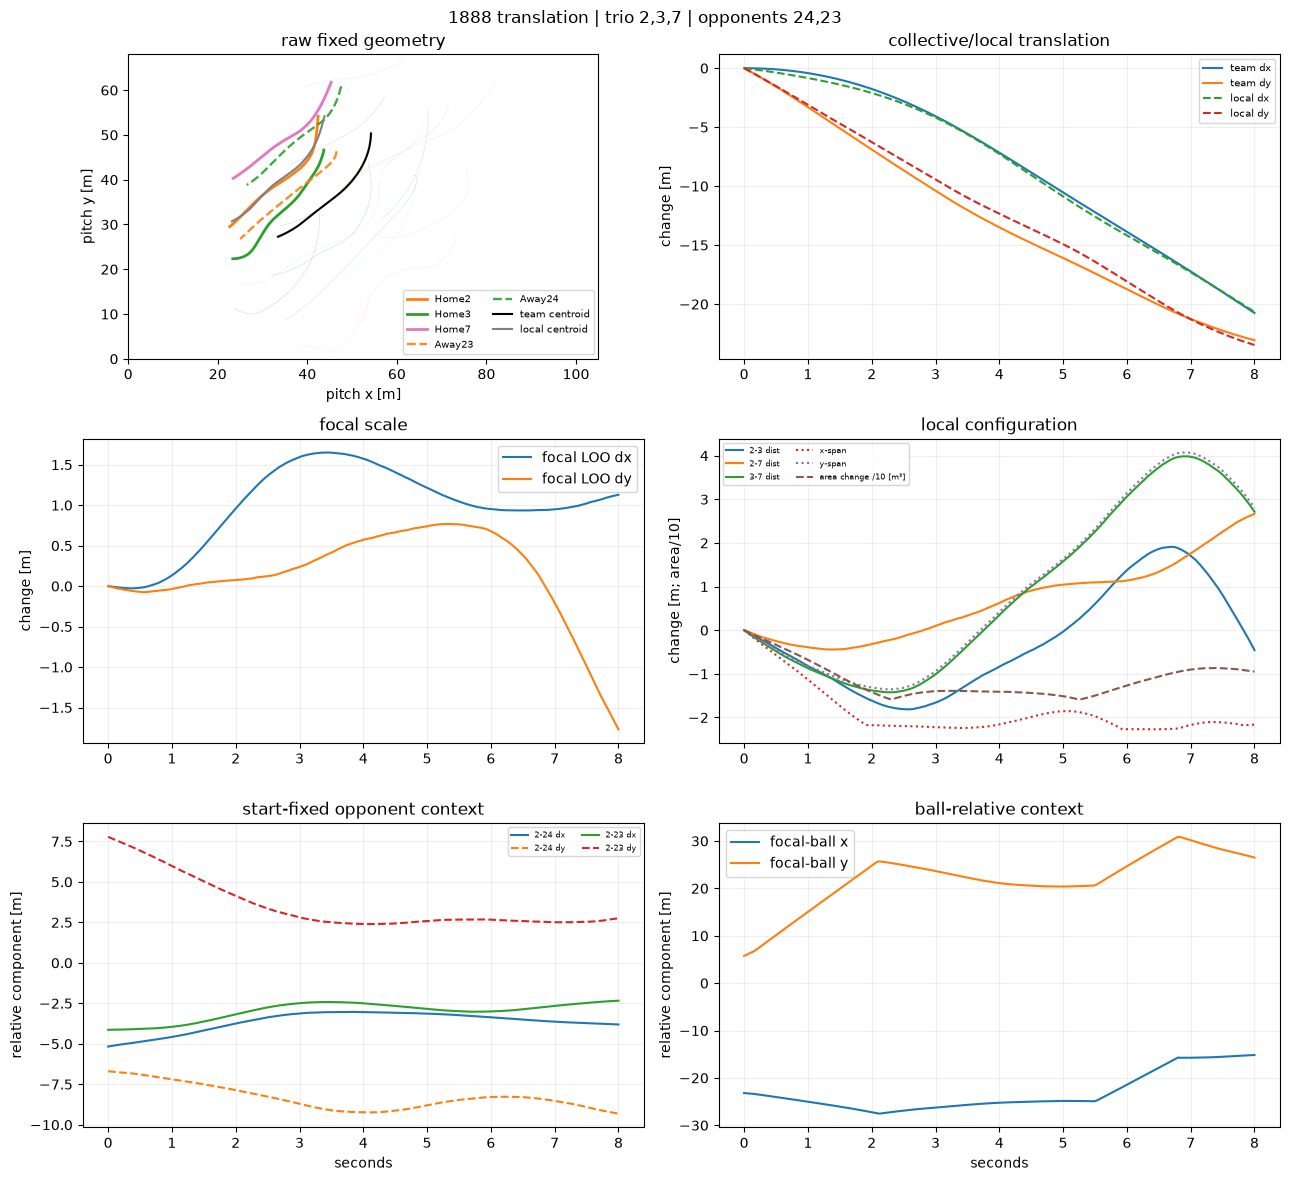

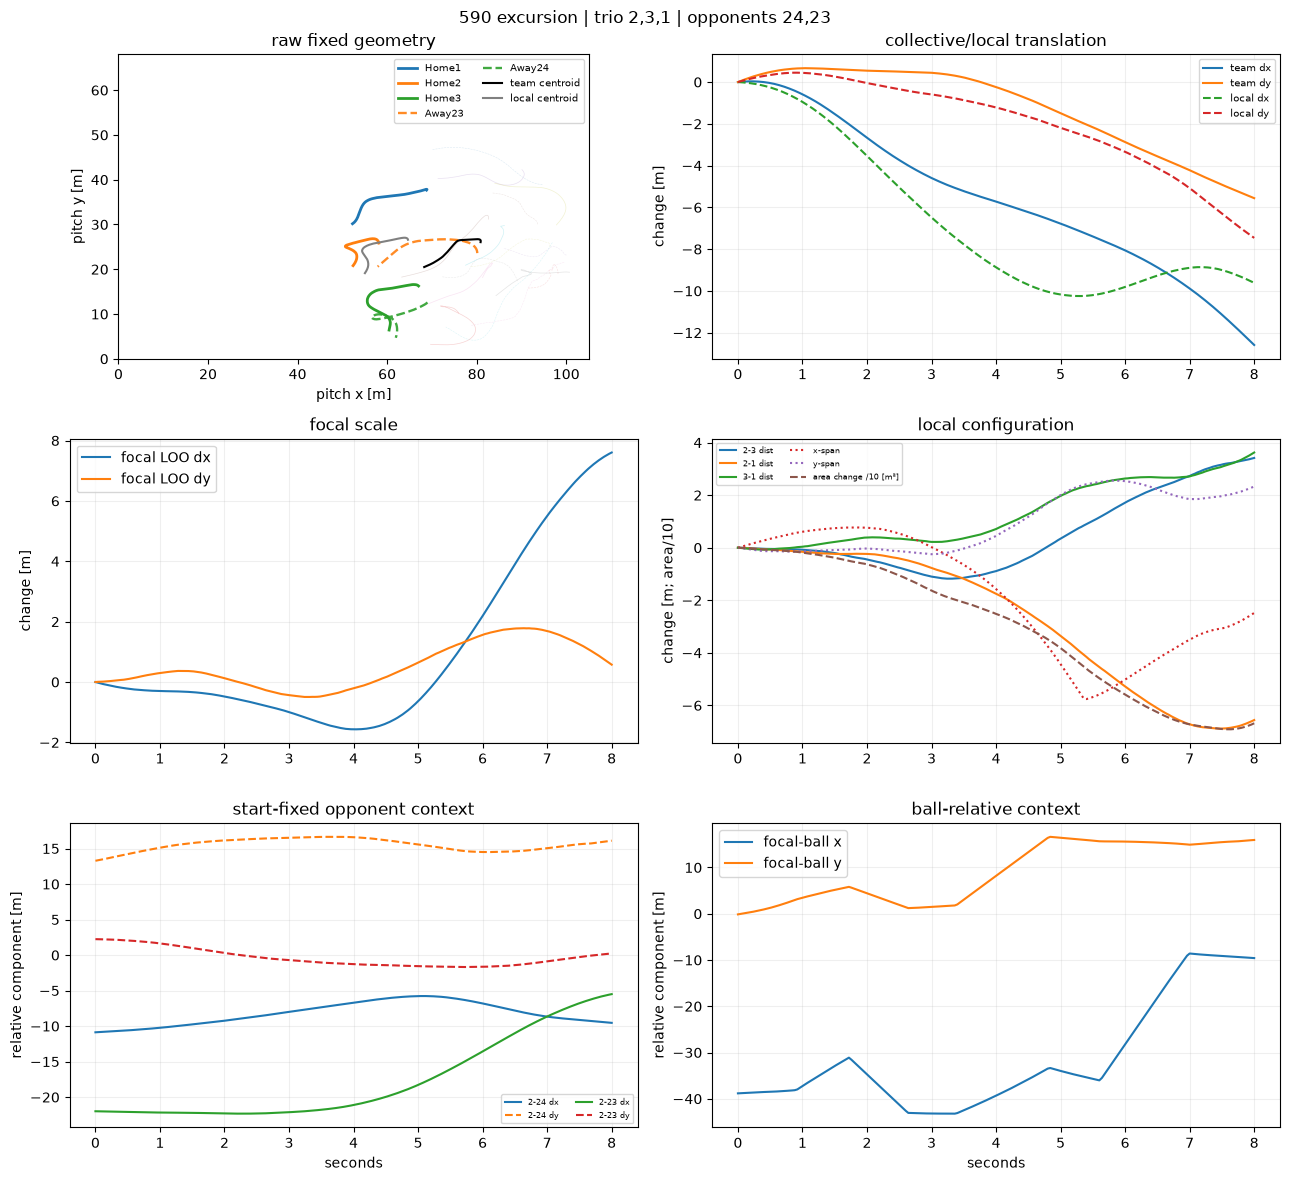

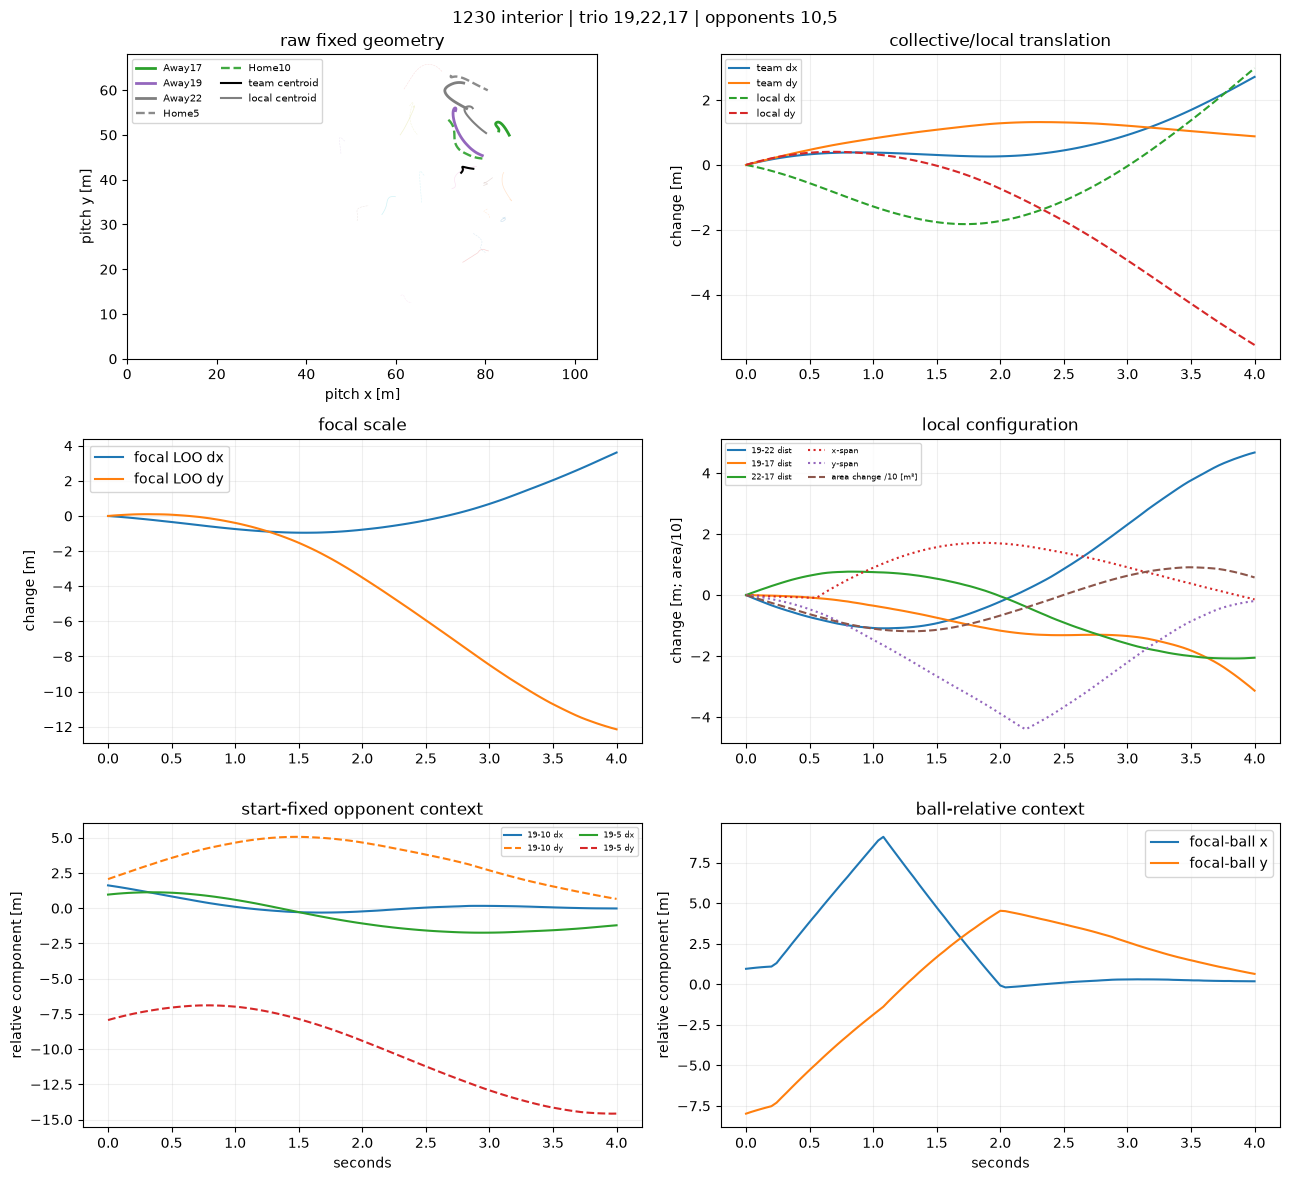

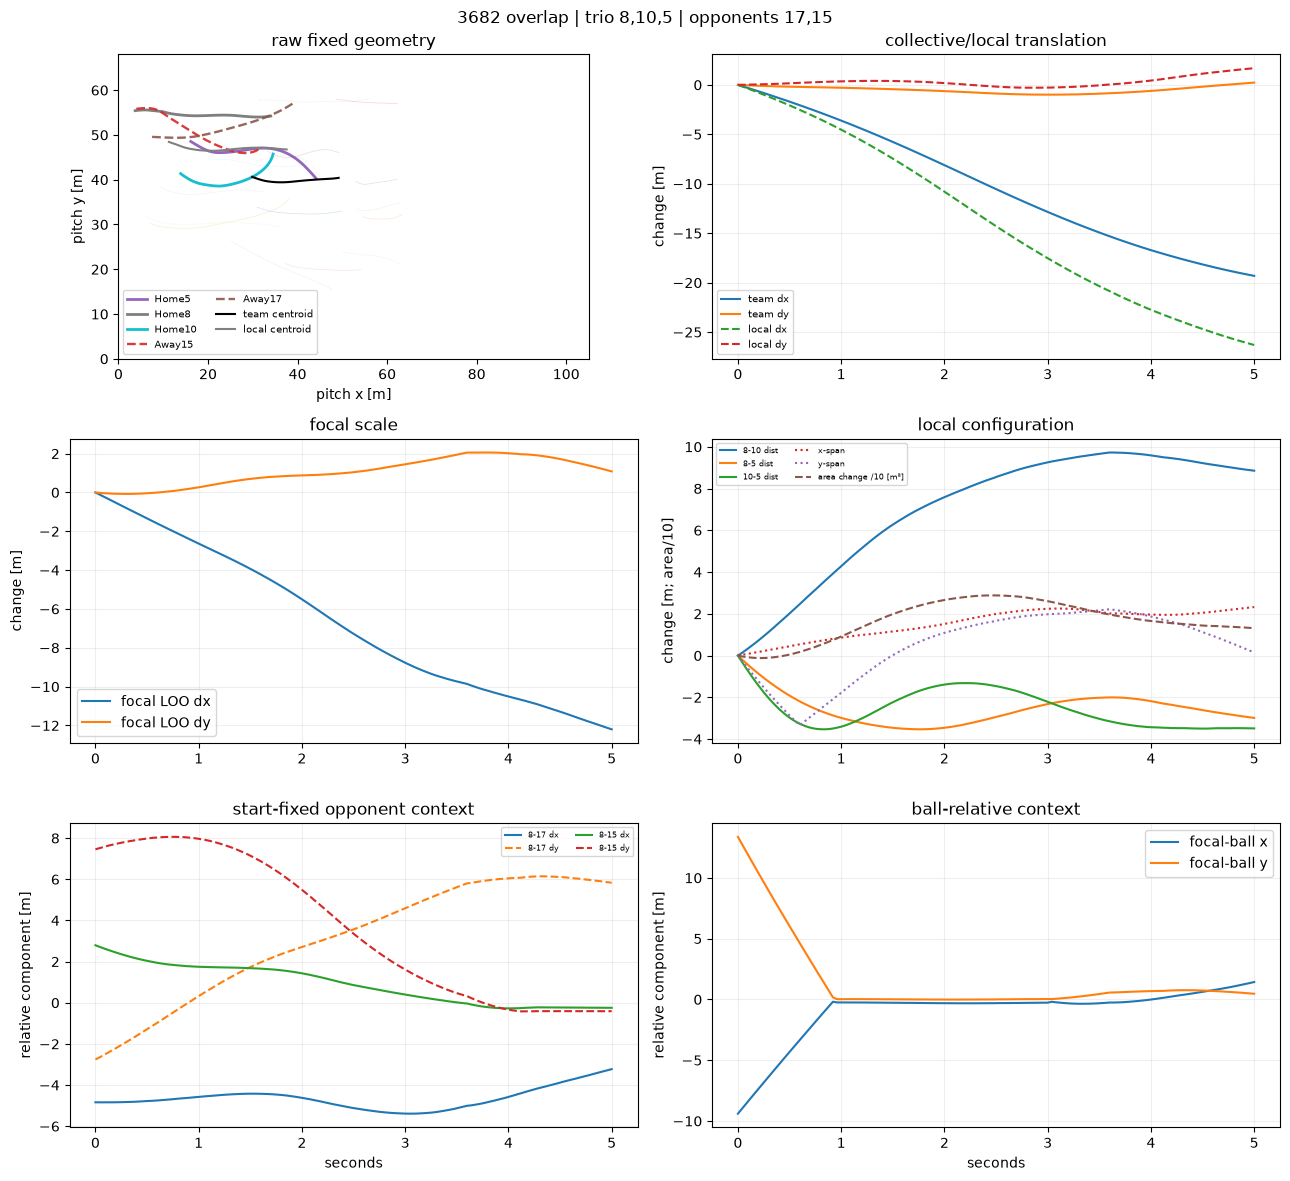

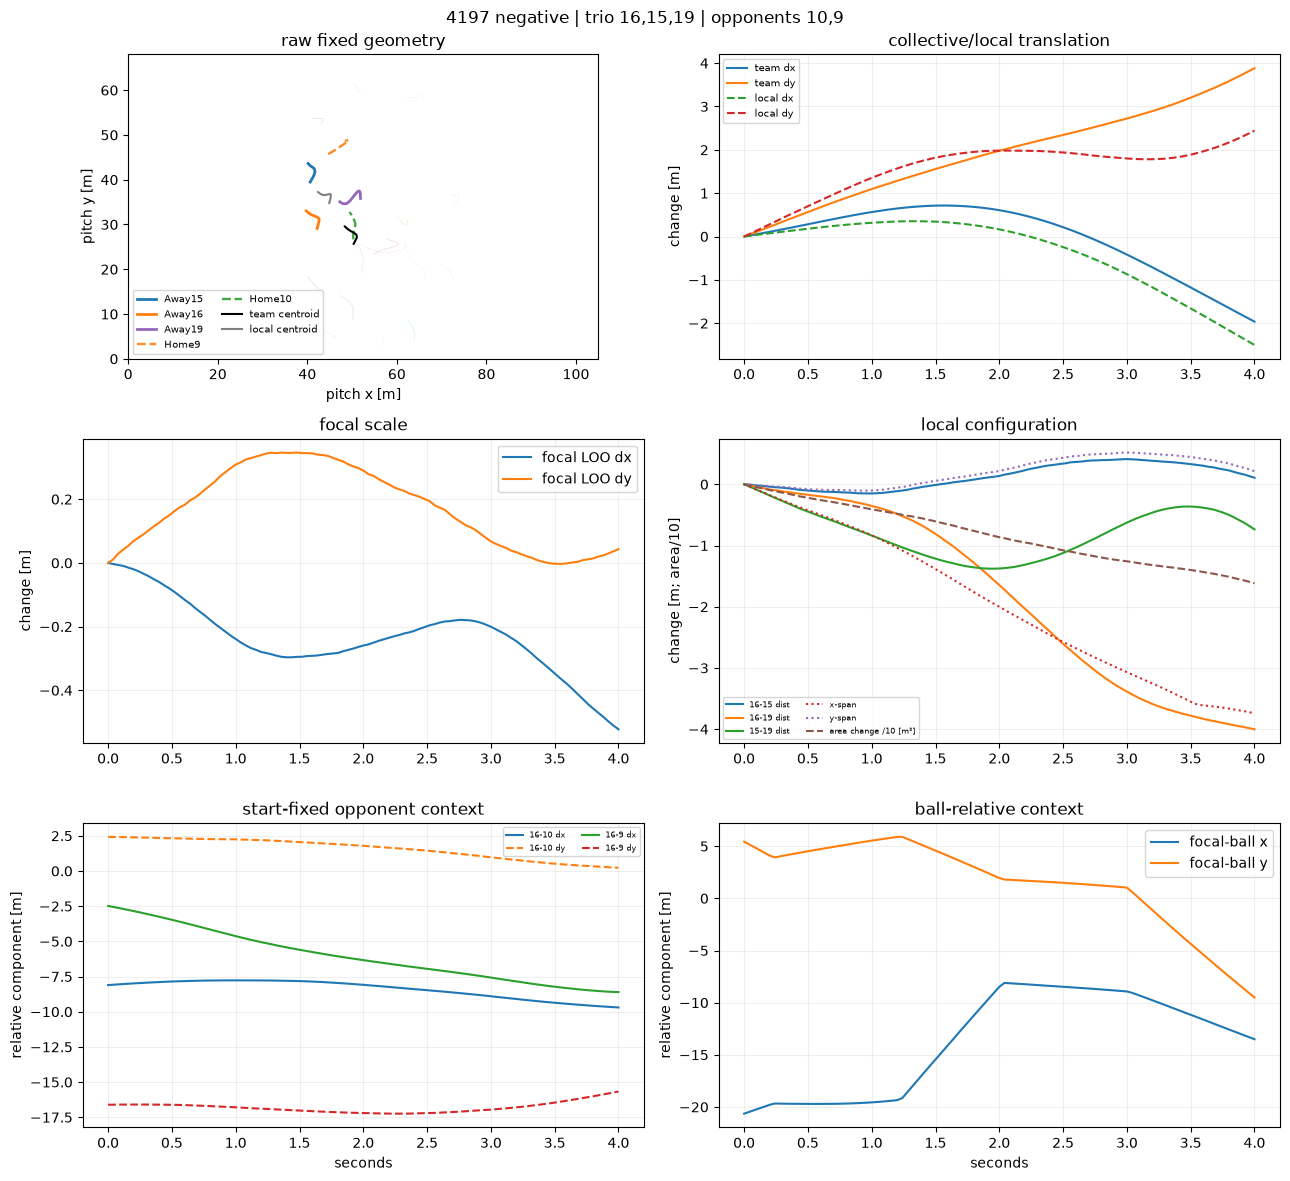

In [4]:
def dser(w,ta,a,tb,b): return np.hypot((w[f'{ta}_{a}_x']-w[f'{tb}_{b}_x'])*L,(w[f'{ta}_{a}_y']-w[f'{tb}_{b}_y'])*W)
def draw(c):
 w,dt,ot,f,trio,opps=c['w'],c['dt'],c['ot'],c['f'],c['trio'],c['opps']; t=w['Time [s]']-c['start']; fig,ax=plt.subplots(3,2,figsize=(13,12)); p=ax[0,0]
 for d in outs(dt): p.plot(w[f'{dt}_{d}_x']*L,w[f'{dt}_{d}_y']*W,lw=2 if d in trio else .5,alpha=1 if d in trio else .2,label=f'{dt}{d}' if d in trio else None)
 for o in outs(ot): p.plot(w[f'{ot}_{o}_x']*L,w[f'{ot}_{o}_y']*W,ls='--',lw=1.7 if o in opps else .4,alpha=.9 if o in opps else .15,label=f'{ot}{o}' if o in opps else None)
 p.plot(w.tcx,w.tcy,c='black',label='team centroid'); p.plot(w.lcx,w.lcy,c='grey',label='local centroid'); p.set(xlim=(0,L),ylim=(0,W),aspect='equal',title='raw fixed geometry',xlabel='pitch x [m]',ylabel='pitch y [m]'); p.legend(fontsize=7,ncol=2)
 q=ax[0,1]; q.plot(t,w.tcx-w.tcx.iloc[0],label='team dx');q.plot(t,w.tcy-w.tcy.iloc[0],label='team dy');q.plot(t,w.lcx-w.lcx.iloc[0],ls='--',label='local dx');q.plot(t,w.lcy-w.lcy.iloc[0],ls='--',label='local dy');q.set(title='collective/local translation',ylabel='change [m]');q.legend(fontsize=7);q.grid(alpha=.2)
 q=ax[1,0];q.plot(t,w.frx-w.frx.iloc[0],label='focal LOO dx');q.plot(t,w.fry-w.fry.iloc[0],label='focal LOO dy');q.set(title='focal scale',ylabel='change [m]');q.legend();q.grid(alpha=.2)
 q=ax[1,1]
 for a,b in itertools.combinations(trio,2): q.plot(t,dser(w,dt,a,dt,b)-dser(w,dt,a,dt,b).iloc[0],label=f'{a}-{b} dist')
 q.plot(t,w['xs']-w['xs'].iloc[0],ls=':',label='x-span');q.plot(t,w['ys']-w['ys'].iloc[0],ls=':',label='y-span');q.plot(t,(w['ar']-w['ar'].iloc[0])/10,ls='--',label='area change /10 [m²]');q.set(title='local configuration',ylabel='change [m; area/10]');q.legend(fontsize=6,ncol=2);q.grid(alpha=.2)
 q=ax[2,0]
 for o in opps:
  q.plot(t,(w[f'{dt}_{f}_x']-w[f'{ot}_{o}_x'])*L,label=f'{f}-{o} dx');q.plot(t,(w[f'{dt}_{f}_y']-w[f'{ot}_{o}_y'])*W,ls='--',label=f'{f}-{o} dy')
 q.set(title='start-fixed opponent context',ylabel='relative component [m]',xlabel='seconds');q.legend(fontsize=6,ncol=2);q.grid(alpha=.2)
 q=ax[2,1]; bx=w[f'{dt}_ball_x']*L;by=w[f'{dt}_ball_y']*W;q.plot(t,w[f'{dt}_{f}_x']*L-bx,label='focal-ball x');q.plot(t,w[f'{dt}_{f}_y']*W-by,label='focal-ball y');q.set(title='ball-relative context',ylabel='relative component [m]',xlabel='seconds');q.legend();q.grid(alpha=.2)
 fig.suptitle(c['short']+' | trio '+','.join(trio)+' | opponents '+','.join(opps));fig.tight_layout();plt.show()
for k in ['1888 translation','590 excursion','1230 interior','3682 overlap','4197 negative']: draw(next(c for c in CASES if c['short']==k))

## Separate-scale descriptive summary

The table reports endpoint or span quantities separately; none are summed, normalized into weights, or thresholded. Ball-relative spans are contextual magnitude only and do not explain direction or intent.

In [5]:
def net(x,y):return float(np.hypot(x.iloc[-1]-x.iloc[0],y.iloc[-1]-y.iloc[0]))
rows=[]
for c in CASES:
 w,dt,ot,f=c['w'],c['dt'],c['ot'],c['f']; pairs=list(itertools.combinations(c['trio'],2))
 pdlt=[dser(w,dt,a,dt,b).iloc[-1]-dser(w,dt,a,dt,b).iloc[0] for a,b in pairs]
 od=[dser(w,dt,f,ot,o).iloc[-1]-dser(w,dt,f,ot,o).iloc[0] for o in c['opps']]
 bx=w[f'{dt}_{f}_x']*L-w[f'{dt}_ball_x']*L;by=w[f'{dt}_{f}_y']*W-w[f'{dt}_ball_y']*W
 rows.append({'case':c['short'],'team centroid net [m]':net(w.tcx,w.tcy),'focal LOO net [m]':net(w.frx,w.fry),'local centroid net [m]':net(w.lcx,w.lcy),'xspan Δ':w['xs'].iloc[-1]-w['xs'].iloc[0],'yspan Δ':w['ys'].iloc[-1]-w['ys'].iloc[0],'area Δ [m²]':w['ar'].iloc[-1]-w['ar'].iloc[0],'pair Δ [m]':', '.join(f'{x:+.2f}' for x in pdlt),'opponent Δdistance [m]':', '.join(f'{x:+.2f}' for x in od),'focal-ball x span [m]':bx.max()-bx.min(),'focal-ball y span [m]':by.max()-by.min()})
summary=pd.DataFrame(rows).set_index('case');display(summary.round(3))

,team centroid net [m],focal LOO net [m],local centroid net [m],xspan Δ,yspan Δ,area Δ [m²],pair Δ [m],opponent Δdistance [m],focal-ball x span [m],focal-ball y span [m]
case,,,,,,,,,,
1888 translation,31.021,2.099,31.259,-2.162,2.802,-9.481,"-0.46, +2.67, +2.71","+1.60, -5.20",12.382,25.127
590 excursion,13.763,7.625,12.173,-2.481,2.331,-66.806,"+3.42, -6.56, +3.62","+1.56, -16.60",34.621,16.759
550.76 tackle,18.993,13.806,26.643,-0.002,-6.992,-30.944,"+5.29, -11.71, -7.44","-9.79, +7.02",4.155,13.281
1230 interior,2.856,12.675,6.306,-0.143,-0.197,5.759,"+4.67, -3.13, -2.05","-1.96, +6.63",9.282,12.508
1232 reference-sensitive,3.786,11.630,6.739,10.203,3.451,26.560,"+3.09, +12.57, +5.31","+0.04, +2.24",8.433,5.282
3682 overlap,19.314,12.247,26.355,2.324,0.150,13.141,"+8.85, -2.99, -3.49","+1.10, -7.49",10.829,13.388
4197 negative,4.353,0.524,3.497,-3.741,0.215,-16.170,"+0.11, -4.00, -0.74","+1.24, +1.08",12.536,15.400


## 1232.28 reference-time sensitivity

The broader scales are unchanged, while local membership alone changes. This directly tests whether an appealing cross-scale narrative depends on reference time.

In [6]:
def local_end(c,ids):
 w,dt=c['w'],c['dt'];P=np.array([[xy(r,dt,p) for p in ids] for _,r in w.iterrows()]); xs=np.ptp(P[:,:,0],1);ys=np.ptp(P[:,:,1],1); ar=np.array([area(x) for x in P]); prs=list(itertools.combinations(ids,2));return {'members':','.join(ids),'xspan Δ':xs[-1]-xs[0],'yspan Δ':ys[-1]-ys[0],'area Δ':ar[-1]-ar[0],'pair Δ':', '.join(f'{dser(w,dt,a,dt,b).iloc[-1]-dser(w,dt,a,dt,b).iloc[0]:+.2f}' for a,b in prs)}
c=next(x for x in CASES if x['short']=='1232 reference-sensitive');display(pd.DataFrame([{'reference':'start',**local_end(c,c['trio'])},{'reference':'anchor',**local_end(c,c['anchor_trio'])}]).set_index('reference'))

,members,xspan Δ,yspan Δ,area Δ,pair Δ
reference,,,,,
start,"19,22,23",10.20285,3.45100,26.560009,"+3.09, +12.57, +5.31"
anchor,"19,21,20",-5.45580,-13.00364,-57.211376,"-12.74, -15.35, -4.83"


## Conservative cross-case assessment

- **1888–1896:** collective-dominant is descriptively supported: collective/local centroids translate far more than focal leave-one-out departure; internal geometry is non-rigid but secondary. Opponent and ball panels do not license an opponent-specific account.
- **590–598:** focal-dominant remains distinguishable at the leave-one-out scale, but local configuration also deforms and does not uniquely isolate the focal player. Fixed opponents are selection-sensitive context.
- **550.76–555.76:** unresolved/adversarial. Collective translation, focal departure, local contraction/expansion, opponent convergence, ball movement, and tackle mechanics are entangled; no ordered cross-scale sequence is defensible.
- **1230.12:** provisionally multi-scale but weak. Collective centroid movement is limited, focal departure is substantial, the prospective local trio deforms with mixed pair changes rather than clean contraction, and fixed opponent relationships change. Ball-relative movement is substantial and equally plausible context. The description does not require Away19/20/21, but prospective membership weakens coherence.
- **1232.28:** unresolved due reference-time sensitivity. Start membership expands while anchor membership contracts strongly; only one selection yields the appealing contraction narrative, so the broader cross-scale interpretation is not robust.
- **3682.88:** local-within-collective is only partially supported. Large collective/local translation coexists with mixed internal and focal/opponent change, but the prospective local set expands in spans/area rather than showing clean compression. Ball/shared movement remains a major alternative.
- **4197.04:** heterogeneous/unresolved is retained. Some scales show deformation or convergence, but directions and neighborhood sensitivity do not form a coherent shared pattern; changing membership is not used to rescue it.

The templates do not fit every case cleanly. Focal- and collective-dominant patterns remain visually distinguishable without cutoffs; local-within-collective is weaker because prospective membership removed the earlier clean compression account.

## Falsification and conclusion

- Scales do not merely duplicate shared movement in the 1888 and 590 contrasts, but collective and ball motion explain substantial portions of several other cases.
- Prospective membership weakens the apparently interesting 1230, 1232, and 3682 multi-scale stories.
- The templates are flexible enough to become labels unless raw contradictions and unresolved outcomes are preserved; tackle, 1232, and 4197 remain unresolved.
- Cross-scale plotting adds information by locating disagreement among scales, but not by establishing a single event or ordered propagation.

## Outcome: B — partially supported

Cross-scale correspondence is a useful empirical bridge only in a limited sense: it distinguishes collective-dominant from focal-dominant geometry and makes local/opponent/ball disagreement auditable. It does not yet make **defensive relational reallocation** operational. That construct remains a descriptive possibility when multiple typed scales change coherently, with explicit negative alternatives and representation sensitivity.

Future hypothesis only: an attacking action may be consequential when defensive geometry changes across multiple scales rather than one local relationship. Nothing here attributes observed correspondence to a specific attacker, infers propagation, or measures influence.